<a href="https://colab.research.google.com/github/ponaalagar/tranfer_learning/blob/main/image_colorization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

from skimage import data as skdata
from skimage.transform import resize
from skimage.color import rgb2lab, lab2rgb, rgb2gray, gray2rgb

from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.layers import (Input, Conv2D, UpSampling2D,
    concatenate, RepeatVector, Reshape)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
DIM = 256

raw = [
    skdata.astronaut(), skdata.chelsea(), skdata.coffee(),
    skdata.colorwheel(), skdata.hubble_deep_field(),
    skdata.immunohistochemistry(), skdata.rocket(),
    skdata.retina(), skdata.skin(), skdata.cat(),
    skdata.brick(), skdata.grass(), skdata.gravel(), skdata.moon(),
]

imgs = []
for img in raw:
    if img.ndim == 2: img = gray2rgb(img)
    elif img.shape[2] == 4: img = img[:,:,:3]
    if img.dtype != np.float64: img = img / 255.0
    imgs.append(resize(img, (DIM, DIM)).astype(np.float64))

imgs = np.array(imgs)
lab  = rgb2lab(imgs)
X    = lab[:,:,:,0].reshape(-1, DIM, DIM, 1)
Y    = lab[:,:,:,1:] / 128

idx = list(range(len(imgs)))
idx_tr, idx_te = train_test_split(idx, test_size=0.3, random_state=2)
X_train, X_test = X[idx_tr], X[idx_te]
Y_train, Y_test = Y[idx_tr], Y[idx_te]
print(f'{len(imgs)} images loaded. Train: {len(X_train)}  Test: {len(X_test)}')


14 images loaded. Train: 9  Test: 5


In [ ]:
FUSE = DIM // 8   # spatial size after 3 stride-2 convolutions

vgg16 = VGG16(weights='imagenet', include_top=True)
vgg16.trainable = False

def embed(X_l):
    gs = np.array([resize(gray2rgb(x[:,:,0]), (224,224,3)) for x in X_l])
    return vgg16.predict(preprocess_input((gs*255).astype(np.float32)), verbose=0)

emb_train = embed(X_train)
emb_test  = embed(X_test)
print('Embeddings:', emb_train.shape)


Embeddings: (9, 1000)


In [ ]:
enc_in = Input(shape=(DIM, DIM, 1), name='grayscale_input')
emb_in = Input(shape=(1000,),        name='embedding_input')

# Encoder (8 Conv2D)
e = Conv2D(64,  (3,3), activation='relu', padding='same', strides=2)(enc_in)
e = Conv2D(128, (3,3), activation='relu', padding='same')(e)
e = Conv2D(128, (3,3), activation='relu', padding='same', strides=2)(e)
e = Conv2D(256, (3,3), activation='relu', padding='same')(e)
e = Conv2D(256, (3,3), activation='relu', padding='same', strides=2)(e)
e = Conv2D(512, (3,3), activation='relu', padding='same')(e)
e = Conv2D(512, (3,3), activation='relu', padding='same')(e)
e = Conv2D(256, (3,3), activation='relu', padding='same')(e)

# Fusion
f = RepeatVector(FUSE * FUSE)(emb_in)
f = Reshape([FUSE, FUSE, 1000])(f)
f = concatenate([e, f], axis=3)
f = Conv2D(256, (1,1), activation='relu', padding='same')(f)

# Decoder (5 Conv2D)
d = Conv2D(128, (3,3), activation='relu', padding='same')(f)
d = UpSampling2D((2,2))(d)
d = Conv2D(64,  (3,3), activation='relu', padding='same')(d)
d = UpSampling2D((2,2))(d)
d = Conv2D(32,  (3,3), activation='relu', padding='same')(d)
d = Conv2D(16,  (3,3), activation='relu', padding='same')(d)
d = Conv2D(2,   (3,3), activation='tanh', padding='same')(d)
d = UpSampling2D((2,2))(d)

model = Model(inputs=[enc_in, emb_in], outputs=d)
model.compile(optimizer='rmsprop', loss='mse')
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ grayscale_input     │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        640 │ grayscale_input[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     73,856 │ conv2d[0][0]      │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_1[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    295,168 │ conv2d_2[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_3[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ conv2d_4[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_input     │ (None, 1000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_5[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 1024,      │          0 │ embedding_input[… │
│ (RepeatVector)      │ 1000)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  1,179,904 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 32, 32,    │          0 │ repeat_vector[0]… │
│                     │ 1000)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_7[0][0],   │
│ (Concatenate)       │ 1256)             │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │    321,792 │ concatenate[0][0] │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │    295,040 │ conv2d_8[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_9[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 64, 64,    │     73,792 │ up_sampling2d[0]

 Total params: 6,541,202 (24.95 MB)

 Trainable params: 6,541,202 (24.95 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200


5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 293ms/step - loss: 0.2105
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 243ms/step - loss: 0.0363
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 239ms/step - loss: 0.0281
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 240ms/step - loss: 0.0277
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 244ms/step - loss: 0.0223
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 263ms/step - loss: 0.0273
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 249ms/step - loss: 0.0223
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 260ms/step - loss: 0.0232
Epoch 9/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 253ms/step - loss: 0.0219
Epoch 10/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 275ms/step - loss: 0.0236
Epoch 11/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 265ms/step - loss: 0.0223
Epoch 12/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 251ms/step - loss: 0.0215
Epoch 13/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 248ms/step - loss: 0.0205
Epoch 14/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 236ms/step - loss: 0.0234
Epoch 15/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 239ms/step - loss: 0.0223
Epoch 16/200
5/5

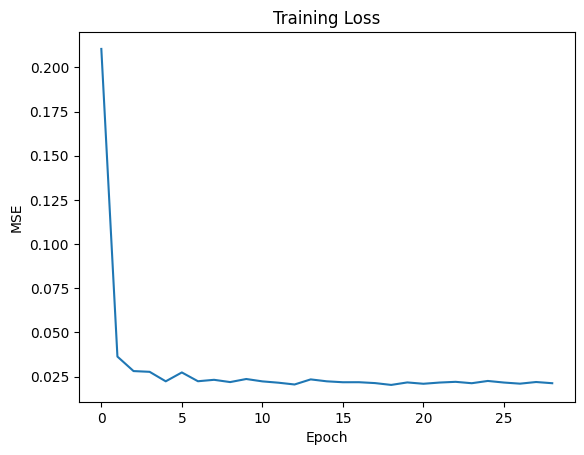

In [ ]:
history = model.fit(
    [X_train, emb_train], Y_train,
    epochs=200, batch_size=2,
    callbacks=[EarlyStopping(monitor='loss', patience=10)]
)
plt.plot(history.history['loss'])
plt.title('Training Loss'); plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step


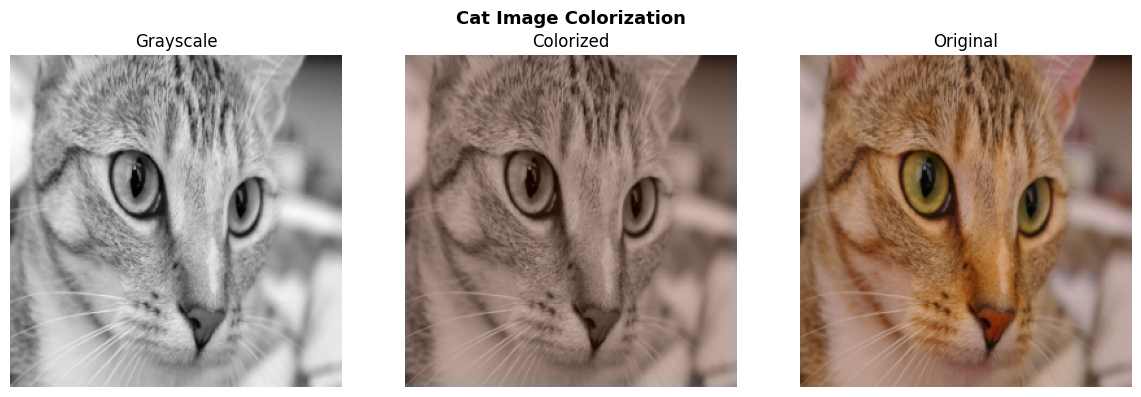

In [ ]:
pred = model.predict([X_test, emb_test]) * 128

CAT_IDX = 9  # cat is at position 9 in the raw list
if CAT_IDX in idx_te:
    i = list(idx_te).index(CAT_IDX)
    result = np.zeros((DIM, DIM, 3))
    result[:,:,0]  = X_test[i,:,:,0]
    result[:,:,1:] = pred[i]
    orig = np.zeros((DIM, DIM, 3))
    orig[:,:,0]    = X_test[i,:,:,0]
    orig[:,:,1:]   = Y_test[i] * 128
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle('Cat Image Colorization', fontsize=13, fontweight='bold')
    ax[0].imshow(X_test[i,:,:,0], cmap='gray'); ax[0].set_title('Grayscale'); ax[0].axis('off')
    ax[1].imshow(lab2rgb(result));              ax[1].set_title('Colorized'); ax[1].axis('off')
    ax[2].imshow(lab2rgb(orig));                ax[2].set_title('Original');  ax[2].axis('off')
    plt.tight_layout(); plt.show()
else:
    print('Cat is in training set. Change random_state in Cell 2 to move it to test set.')
